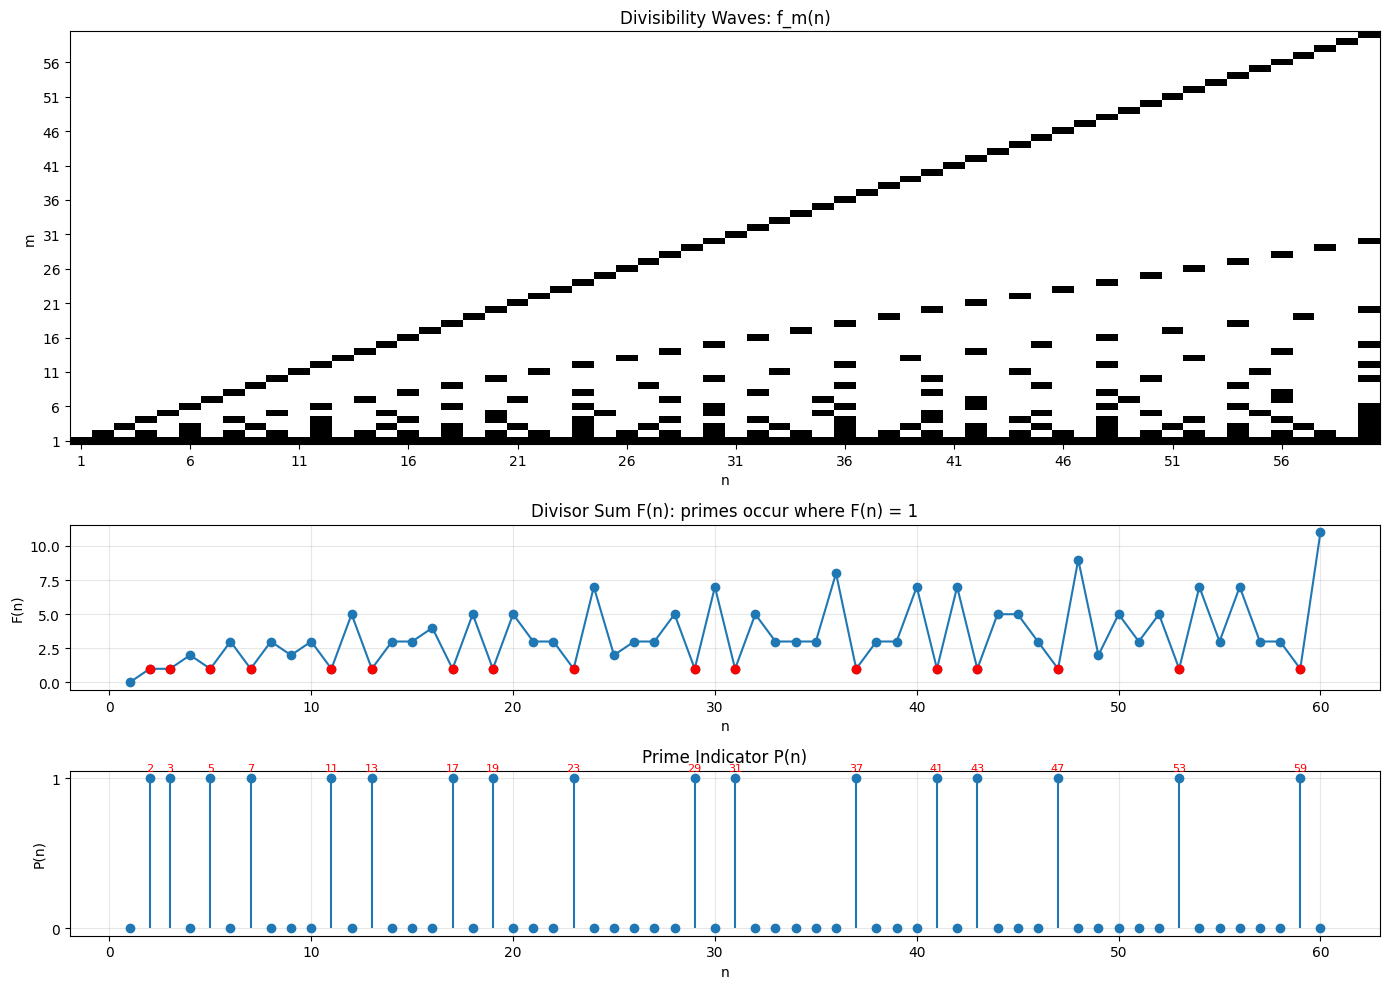

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math


N = 60  # numbers to test: 1, 2, ..., N


def f(m, n):
    """
    Wave/divisibility function:

    f_m(n) = 1 if m divides n
           = 0 otherwise

    Algebraic version:
    f_m(n) = (1/m) * sum_{j=0}^{m-1} exp(2*pi*i*j*n/m)
    """
    total = 0

    for j in range(m):
        total += np.exp(2j * np.pi * j * n / m)

    # Remove tiny floating point errors
    value = round(total.real / m)

    return value


def divisor_sum(n):
    """
    F(n) = sum from m=2 to n of f_m(n)

    This counts the divisors of n except 1.
    Prime numbers have F(n) = 1.
    """
    return sum(f(m, n) for m in range(2, n + 1))


def prime_indicator(n):
    """
    P(n) = product from m=2 to floor(sqrt(n)) of (1 - f_m(n))

    Returns:
    1 if n is prime
    0 if n is composite
    """
    if n < 2:
        return 0

    for m in range(2, int(math.sqrt(n)) + 1):
        if f(m, n) == 1:
            return 0

    return 1


numbers = list(range(1, N + 1))
rows = list(range(1, N + 1))

# Matrix of waves: row m, column n
wave_matrix = np.zeros((N, N))

for row_index, m in enumerate(rows):
    for col_index, n in enumerate(numbers):
        wave_matrix[row_index, col_index] = f(m, n)

F_values = [divisor_sum(n) for n in numbers]
P_values = [prime_indicator(n) for n in numbers]
primes = [n for n in numbers if prime_indicator(n) == 1]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), height_ratios=[5, 2, 2])

# 1. Divisibility wave matrix
ax = axes[0]
im = ax.imshow(wave_matrix, cmap="Greys", aspect="auto", origin="lower")

ax.set_title("Divisibility Waves: f_m(n)")
ax.set_xlabel("n")
ax.set_ylabel("m")

ax.set_xticks(range(0, N, 5))
ax.set_xticklabels(range(1, N + 1, 5))

ax.set_yticks(range(0, N, 5))
ax.set_yticklabels(range(1, N + 1, 5))

# 2. Divisor sum F(n)
ax = axes[1]
ax.plot(numbers, F_values, marker="o", linewidth=1.5)
ax.set_title("Divisor Sum F(n): primes occur where F(n) = 1")
ax.set_xlabel("n")
ax.set_ylabel("F(n)")
ax.grid(True, alpha=0.3)

for p in primes:
    ax.scatter(p, F_values[p - 1], color="red", zorder=3)

# 3. Prime indicator P(n)
ax = axes[2]
ax.stem(numbers, P_values, basefmt=" ")
ax.set_title("Prime Indicator P(n)")
ax.set_xlabel("n")
ax.set_ylabel("P(n)")
ax.set_yticks([0, 1])
ax.grid(True, alpha=0.3)

for p in primes:
    ax.text(p, 1.05, str(p), ha="center", fontsize=8, color="red")

plt.tight_layout()
plt.show()

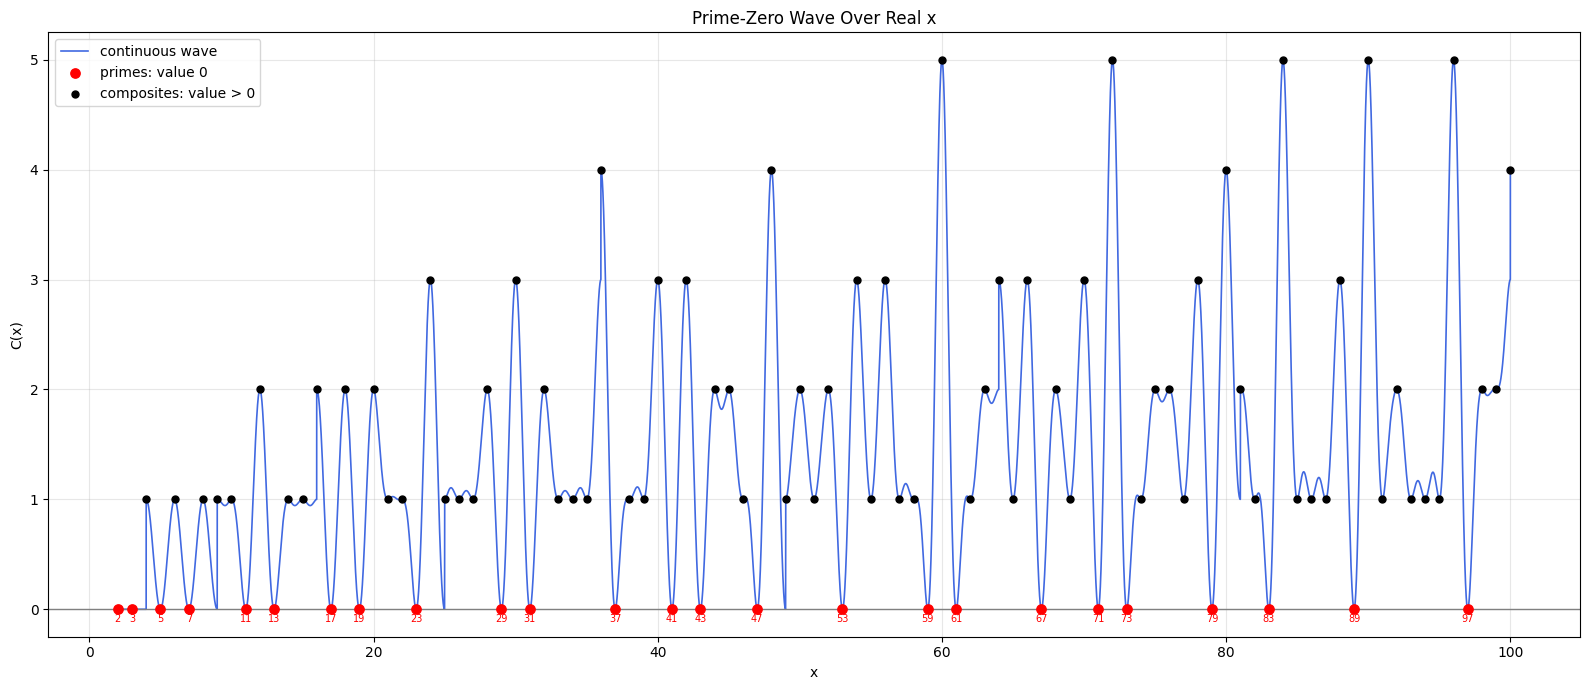

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt


N_MAX = 100
SAMPLES_PER_UNIT = 300


def wave(m, x):
    x = np.asarray(x, dtype=float)

    numerator = np.sin(np.pi * x)
    denominator = m * np.sin(np.pi * x / m)

    y = np.zeros_like(x)

    regular = np.abs(denominator) > 1e-12
    y[regular] = (numerator[regular] / denominator[regular]) ** 2
    y[~regular] = 1.0

    return np.clip(y, 0, 1)


def prime_zero_wave(x):
    x = np.asarray(x, dtype=float)
    total = np.zeros_like(x)

    for m in range(2, int(math.sqrt(N_MAX)) + 1):
        active = x >= m * m
        total += np.where(active, wave(m, x), 0)

    return total


def is_prime(n):
    if n < 2:
        return False

    for m in range(2, int(math.sqrt(n)) + 1):
        if n % m == 0:
            return False

    return True


x = np.linspace(2, N_MAX, (N_MAX - 2) * SAMPLES_PER_UNIT + 1)
y = prime_zero_wave(x)

integers = np.arange(2, N_MAX + 1)
integer_y = prime_zero_wave(integers)

primes = np.array([n for n in integers if is_prime(n)])
composites = np.array([n for n in integers if not is_prime(n)])


plt.figure(figsize=(16, 7))

plt.plot(x, y, color="royalblue", linewidth=1.2, label="continuous wave")

plt.scatter(
    primes,
    prime_zero_wave(primes),
    color="red",
    s=45,
    zorder=5,
    label="primes: value 0"
)

plt.scatter(
    composites,
    prime_zero_wave(composites),
    color="black",
    s=25,
    zorder=4,
    label="composites: value > 0"
)

for p in primes:
    plt.text(p, -0.12, str(p), ha="center", fontsize=7, color="red")

plt.axhline(0, color="gray", linewidth=1)

plt.title("Prime-Zero Wave Over Real x")
plt.xlabel("x")
plt.ylabel("C(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

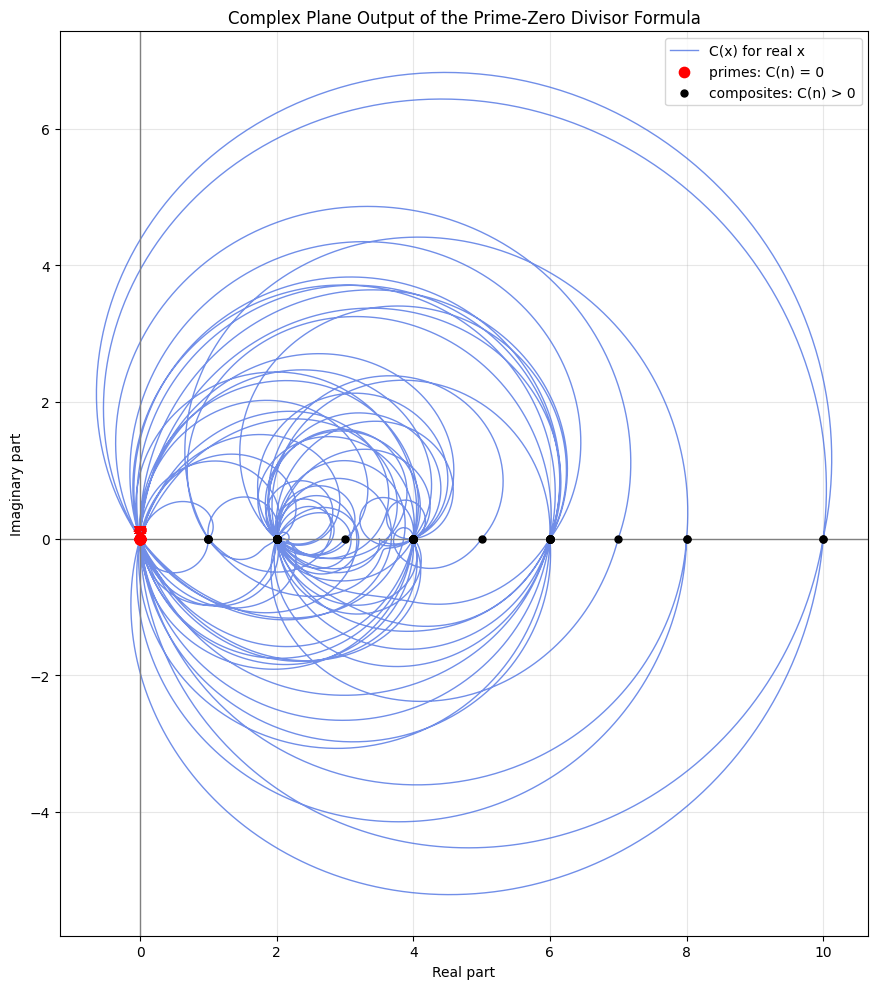

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt


N_MAX = 80
SAMPLES_PER_UNIT = 250


def f_complex(m, x):
    """
    Complex divisibility wave:

    f_m(x) = (1/m) * sum_{j=0}^{m-1} exp(2*pi*i*j*x/m)

    At integer n:
      f_m(n) = 1 if m divides n
      f_m(n) = 0 otherwise

    For real x, f_m(x) moves through the complex plane.
    """
    x = np.asarray(x, dtype=float)
    total = np.zeros_like(x, dtype=complex)

    for j in range(m):
        total += np.exp(2j * np.pi * j * x / m)

    return total / m


def C_complex(x):
    """
    Your prime-zero divisor formula, extended to real x:

    C(x) = sum from m=2 to floor(x)-1 of f_m(x)

    At integer n:
      C(n) = 0 for primes
      C(n) > 0 for composites
    """
    x = np.asarray(x, dtype=float)
    total = np.zeros_like(x, dtype=complex)

    for m in range(2, N_MAX):
        active = x >= m + 1
        total += np.where(active, f_complex(m, x), 0)

    return total


def is_prime(n):
    if n < 2:
        return False

    for m in range(2, int(math.sqrt(n)) + 1):
        if n % m == 0:
            return False

    return True


x = np.linspace(
    2,
    N_MAX,
    (N_MAX - 2) * SAMPLES_PER_UNIT + 1
)

z = C_complex(x)

integers = np.arange(2, N_MAX + 1)
z_integers = C_complex(integers)

primes = np.array([n for n in integers if is_prime(n)])
composites = np.array([n for n in integers if not is_prime(n)])

z_primes = C_complex(primes)
z_composites = C_complex(composites)


plt.figure(figsize=(10, 10))

plt.plot(
    z.real,
    z.imag,
    color="royalblue",
    linewidth=1,
    alpha=0.75,
    label="C(x) for real x"
)

plt.scatter(
    z_primes.real,
    z_primes.imag,
    color="red",
    s=55,
    zorder=5,
    label="primes: C(n) = 0"
)

plt.scatter(
    z_composites.real,
    z_composites.imag,
    color="black",
    s=25,
    zorder=4,
    label="composites: C(n) > 0"
)

for n, value in zip(primes, z_primes):
    plt.text(
        value.real,
        value.imag + 0.08,
        str(n),
        ha="center",
        fontsize=8,
        color="red"
    )

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Complex Plane Output of the Prime-Zero Divisor Formula")
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

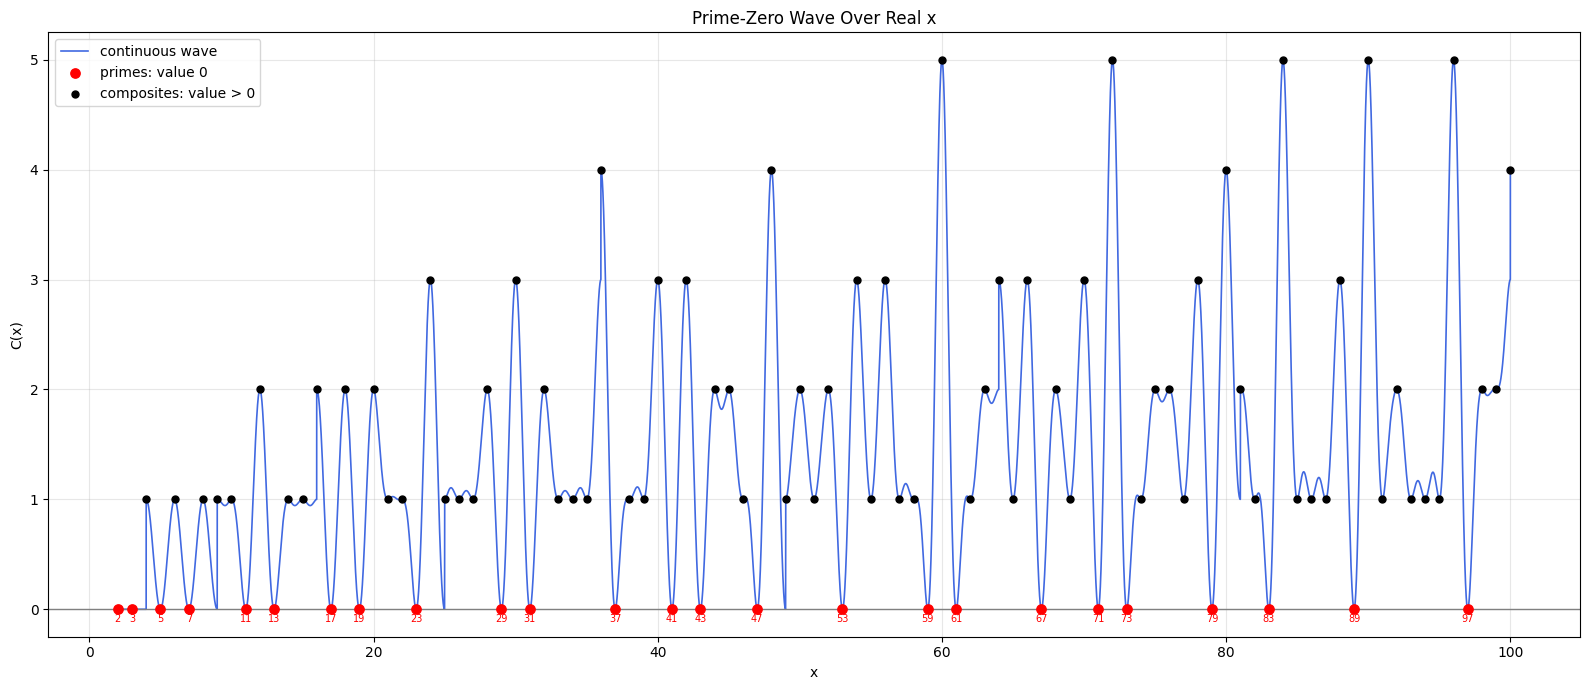

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt


N_MAX = 100
SAMPLES_PER_UNIT = 300


def wave(m, x):
    x = np.asarray(x, dtype=float)

    numerator = np.sin(np.pi * x)
    denominator = m * np.sin(np.pi * x / m)

    y = np.zeros_like(x)

    regular = np.abs(denominator) > 1e-12
    y[regular] = (numerator[regular] / denominator[regular]) ** 2
    y[~regular] = 1.0

    return np.clip(y, 0, 1)


def prime_zero_wave(x):
    x = np.asarray(x, dtype=float)
    total = np.zeros_like(x)

    for m in range(2, int(math.sqrt(N_MAX)) + 1):
        active = x >= m * m
        total += np.where(active, wave(m, x), 0)

    return total


def is_prime(n):
    if n < 2:
        return False

    for m in range(2, int(math.sqrt(n)) + 1):
        if n % m == 0:
            return False

    return True


x = np.linspace(2, N_MAX, (N_MAX - 2) * SAMPLES_PER_UNIT + 1)
y = prime_zero_wave(x)

integers = np.arange(2, N_MAX + 1)
integer_y = prime_zero_wave(integers)

primes = np.array([n for n in integers if is_prime(n)])
composites = np.array([n for n in integers if not is_prime(n)])


plt.figure(figsize=(16, 7))

plt.plot(x, y, color="royalblue", linewidth=1.2, label="continuous wave")

plt.scatter(
    primes,
    prime_zero_wave(primes),
    color="red",
    s=45,
    zorder=5,
    label="primes: value 0"
)

plt.scatter(
    composites,
    prime_zero_wave(composites),
    color="black",
    s=25,
    zorder=4,
    label="composites: value > 0"
)

for p in primes:
    plt.text(p, -0.12, str(p), ha="center", fontsize=7, color="red")

plt.axhline(0, color="gray", linewidth=1)

plt.title("Prime-Zero Wave Over Real x")
plt.xlabel("x")
plt.ylabel("C(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

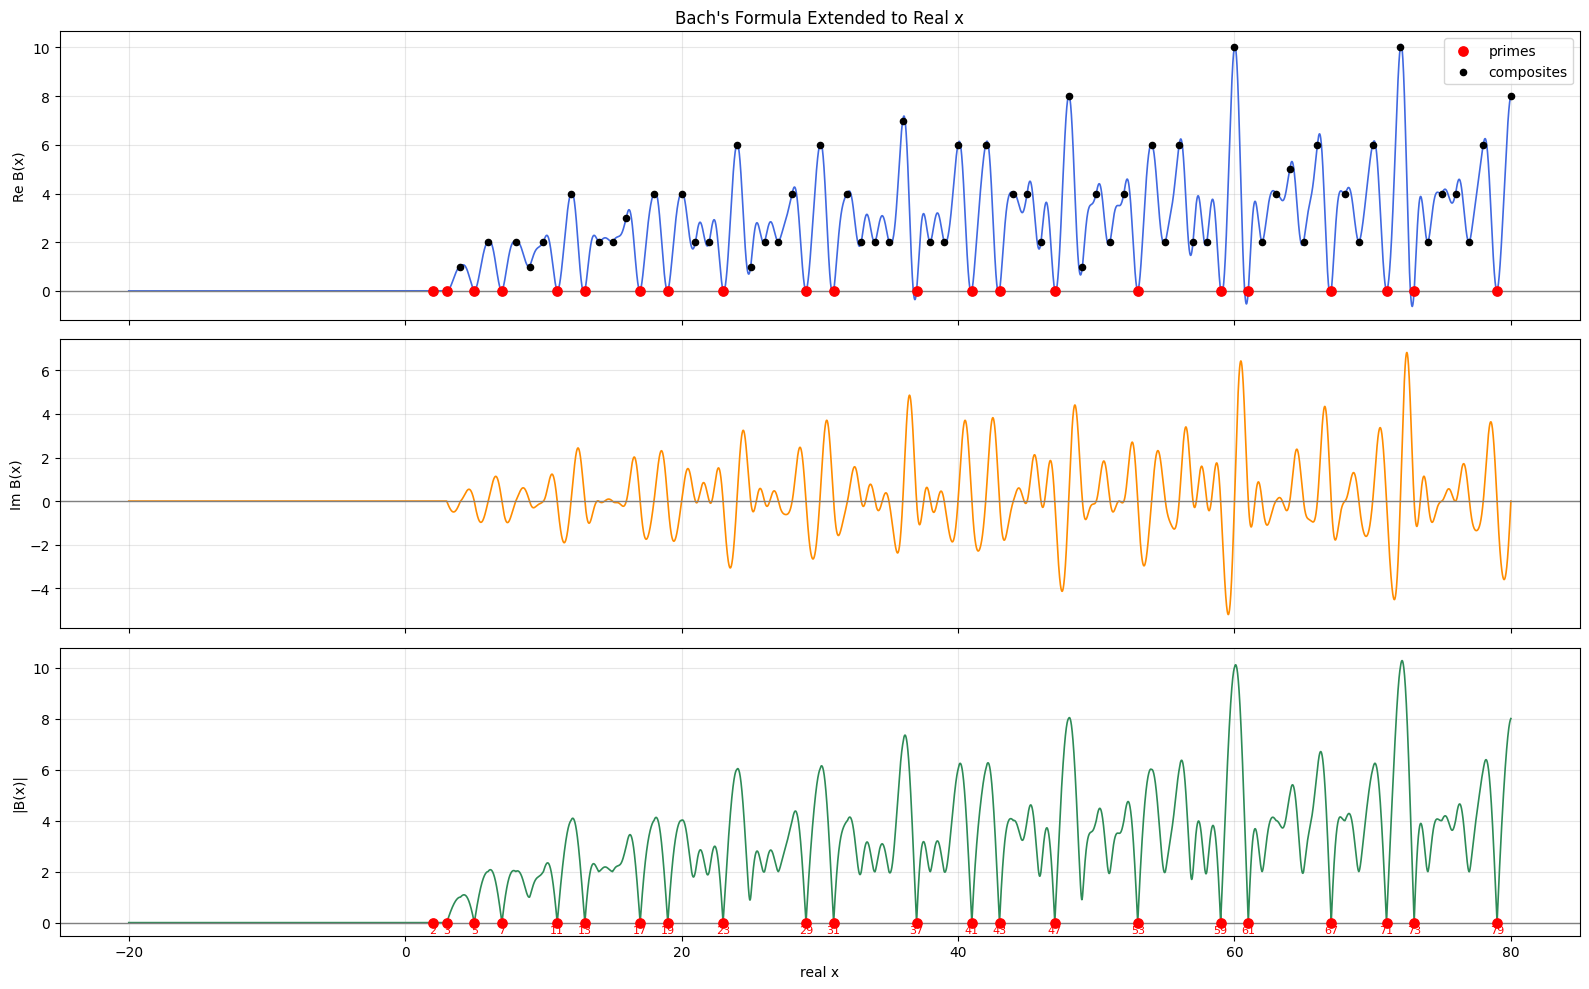

In [5]:
import math

import matplotlib.pyplot as plt
import numpy as np


# Change these if you want a wider or denser plot.
X_MIN = -20.0
X_MAX = 80.0
SAMPLES_PER_UNIT = 120


def f_m(m, x):
    """
    Complex divisibility wave:

        f_m(x) = (1 / m) * sum_{j=0}^{m-1} exp(2*pi*i*j*x/m)
    """
    x = np.asarray(x, dtype=float)
    total = np.zeros_like(x, dtype=complex)

    for j in range(m):
        total += np.exp(2j * np.pi * j * x / m)

    return total / m


def bach_formula(x):
    """
    Real-extension of Bach's formula:

        B(x) = sum_{m=2}^{floor(x)-1} f_m(x)

    At every integer n >= 2, this equals your original formula.
    """
    x = np.asarray(x, dtype=float)
    result = np.zeros_like(x, dtype=complex)

    max_m = int(math.floor(np.max(x))) - 1

    if max_m < 2:
        return result

    for m in range(2, max_m + 1):
        active = np.floor(x) >= m + 1
        result += np.where(active, f_m(m, x), 0)

    return result


def bach_formula_at_integer(n):
    """
    Exact integer version.
    Counts divisors of n excluding 1 and n.
    """
    if n < 2:
        return None

    count = 0

    for m in range(2, n):
        if n % m == 0:
            count += 1

    return count


def is_prime(n):
    """
    Standard convention:
    primes are positive integers greater than 1.
    """
    if n < 2:
        return False

    for m in range(2, int(math.sqrt(n)) + 1):
        if n % m == 0:
            return False

    return True


def main():
    sample_count = int((X_MAX - X_MIN) * SAMPLES_PER_UNIT) + 1
    x = np.linspace(X_MIN, X_MAX, sample_count)
    z = bach_formula(x)

    integer_min = math.ceil(X_MIN)
    integer_max = math.floor(X_MAX)
    integers = np.arange(integer_min, integer_max + 1)

    positive_integers = np.array([n for n in integers if n >= 2])
    primes = np.array([n for n in positive_integers if is_prime(n)])
    composites = np.array([n for n in positive_integers if n > 1 and not is_prime(n)])

    prime_values = np.array([bach_formula_at_integer(int(n)) for n in primes])
    composite_values = np.array([bach_formula_at_integer(int(n)) for n in composites])

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(x, z.real, color="royalblue", linewidth=1.2)
    axes[0].scatter(primes, prime_values, color="red", s=45, zorder=5, label="primes")
    axes[0].scatter(composites, composite_values, color="black", s=20, zorder=4, label="composites")
    axes[0].axhline(0, color="gray", linewidth=1)
    axes[0].set_ylabel("Re B(x)")
    axes[0].set_title("Bach's Formula Extended to Real x")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(x, z.imag, color="darkorange", linewidth=1.2)
    axes[1].axhline(0, color="gray", linewidth=1)
    axes[1].set_ylabel("Im B(x)")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(x, np.abs(z), color="seagreen", linewidth=1.2)
    axes[2].scatter(primes, np.zeros_like(primes), color="red", s=45, zorder=5)
    axes[2].axhline(0, color="gray", linewidth=1)
    axes[2].set_xlabel("real x")
    axes[2].set_ylabel("|B(x)|")
    axes[2].grid(True, alpha=0.3)

    for p in primes:
        axes[2].text(p, -0.08, str(p), ha="center", va="top", fontsize=8, color="red")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:

    Returns 1 if the product is numerically near 1, otherwise 0.
    This mirrors the algebraic formula, but it is slower than the exact version.
    """
    if n < 2:
        return 0

    product = 1 + 0j
    for m in range(2, n):
        product *= 1 - divisibility_wave(m, n)

    return 1 if abs(product - 1) < tolerance else 0


def bach_prime_indicator_exact(n):
    """
    Exact integer version of the same Bach product.

    The factor for m is:
        1 - 1 = 0 if m divides n
        1 - 0 = 1 otherwise

    So the product is 1 exactly when no m from 2 to n - 1 divides n.
    """
    if n < 2:
        return 0

    for m in range(2, n):
        if n % m == 0:
            return 0

    return 1


def bach_prime_count_values(limit, use_literal_formula=False):
    """
    Return x-values and pi_B(x)-values for x = 0, 1, ..., limit.
    """
    indicator = (
        bach_prime_indicator_literal
        if use_literal_formula
        else bach_prime_indicator_exact
    )

    xs = list(range(limit + 1))
    counts = []
    running_total = 0

    for n in xs:
        running_total += indicator(n)
        counts.append(running_total)

    return xs, counts


def main():
    parser = argparse.ArgumentParser(
        description="Plot Bach's algebraic prime counting function."
    )
    parser.add_argument(
        "--limit",
        type=int,
        default=100,
        help="Largest x-value to plot. Default: 100",
    )
    parser.add_argument(
        "--literal",
        action="store_true",
        help=(
            "Use the literal complex roots-of-unity product. "
            "This is slower and intended for small limits."
        ),
    )
    parser.add_argument(
        "--save",
        default="",
        help="Optional output path, for example bach_prime_counting.png",
    )
    args = parser.parse_args()

    if args.limit < 2:
        raise ValueError("--limit must be at least 2")

    if args.literal and args.limit > 80:
        print(
            "Warning: --literal is slow for large limits. "
            "Consider using --limit 80 or less."
        )

    xs, counts = bach_prime_count_values(args.limit, args.literal)

    primes_x = []
    primes_y = []
    for x, count in zip(xs, counts):
        if bach_prime_indicator_exact(x):
            primes_x.append(x)
            primes_y.append(count)

    plt.figure(figsize=(11, 6))
    plt.step(xs, counts, where="post", linewidth=2.0, label=r"$\pi_B(x)$")
    plt.scatter(primes_x, primes_y, color="crimson", s=28, zorder=3, label="prime jumps")

    plt.title("Bach-Form Prime Counting Function")
    plt.xlabel("x")
    plt.ylabel(r"$\pi_B(x)$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if args.save:
        plt.savefig(args.save, dpi=180)
        print(f"Saved plot to {args.save}")
    else:
        plt.show()


if __name__ == "__main__":
    main()

SyntaxError: invalid syntax (3172903765.py, line 1)

In [7]:
"""
Plot the Bach-form prime counting function.

This script plots

    pi_B(x) = sum_{2 <= n <= x} product_{m=2}^{n-1}
              (1 - (1/m) * sum_{j=0}^{m-1} exp(2*pi*i*j*n/m))

At integer n, the inner roots-of-unity average is 1 when m divides n
and 0 otherwise. Therefore the product is 1 exactly when n is prime.

Python: 3.9+
Dependencies:
    pip install matplotlib
"""

import argparse
import cmath
import math
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib-cache"))

if "--save" in sys.argv:
    import matplotlib

    matplotlib.use("Agg")

import matplotlib.pyplot as plt


def divisibility_wave(m, n):
    """
    Literal roots-of-unity divisibility detector:

        (1/m) * sum_{j=0}^{m-1} exp(2*pi*i*j*n/m)

    Mathematically this is exactly 1 if m divides n, and exactly 0 otherwise.
    Numerically it may return tiny floating-point noise near 0.
    """
    total = 0j
    for j in range(m):
        total += cmath.exp(2j * math.pi * j * n / m)
    return total / m


def bach_prime_indicator_literal(n, tolerance=1e-8):
    """
    Direct numerical version of the boxed formula's product.
    """
    if n < 2:
        return 0

    product = 1 + 0j
    for m in range(2, n):
        product *= 1 - divisibility_wave(m, n)

    return 1 if abs(product - 1) < tolerance else 0


def bach_prime_indicator_exact(n):
    """
    Exact integer version of the same Bach product.
    """
    if n < 2:
        return 0

    for m in range(2, n):
        if n % m == 0:
            return 0

    return 1


def bach_prime_count_values(limit, use_literal_formula=False):
    """
    Return x-values and pi_B(x)-values for x = 0, 1, ..., limit.
    """
    indicator = (
        bach_prime_indicator_literal
        if use_literal_formula
        else bach_prime_indicator_exact
    )

    xs = list(range(limit + 1))
    counts = []
    running_total = 0

    for n in xs:
        running_total += indicator(n)
        counts.append(running_total)

    return xs, counts


def main():
    parser = argparse.ArgumentParser(
        description="Plot Bach's algebraic prime counting function."
    )
    parser.add_argument(
        "--limit",
        type=int,
        default=100,
        help="Largest x-value to plot. Default: 100",
    )
    parser.add_argument(
        "--literal",
        action="store_true",
        help="Use the literal complex roots-of-unity product.",
    )
    parser.add_argument(
        "--save",
        default="",
        help="Optional output path, for example bach_prime_counting.png",
    )
    args = parser.parse_args()

    if args.limit < 2:
        raise ValueError("--limit must be at least 2")

    xs, counts = bach_prime_count_values(args.limit, args.literal)

    primes_x = []
    primes_y = []

    for x, count in zip(xs, counts):
        if bach_prime_indicator_exact(x):
            primes_x.append(x)
            primes_y.append(count)

    plt.figure(figsize=(11, 6))
    plt.step(xs, counts, where="post", linewidth=2.0, label=r"$\pi_B(x)$")
    plt.scatter(
        primes_x,
        primes_y,
        color="crimson",
        s=28,
        zorder=3,
        label="prime jumps",
    )

    plt.title("Bach-Form Prime Counting Function")
    plt.xlabel("x")
    plt.ylabel(r"$\pi_B(x)$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if args.save:
        plt.savefig(args.save, dpi=180)
        print(f"Saved plot to {args.save}")
    else:
        plt.show()


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--limit LIMIT] [--literal] [--save SAVE]
ipykernel_launcher.py: error: unrecognized arguments: --f=/Users/bachgonz/Library/Jupyter/runtime/kernel-v3186395c15319bcbb036c21f546110ef0d2c85b20.json


SystemExit: 2

/Users/bachgonz/Library/Python/3.9/lib/python/site-packages/IPython/core/interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


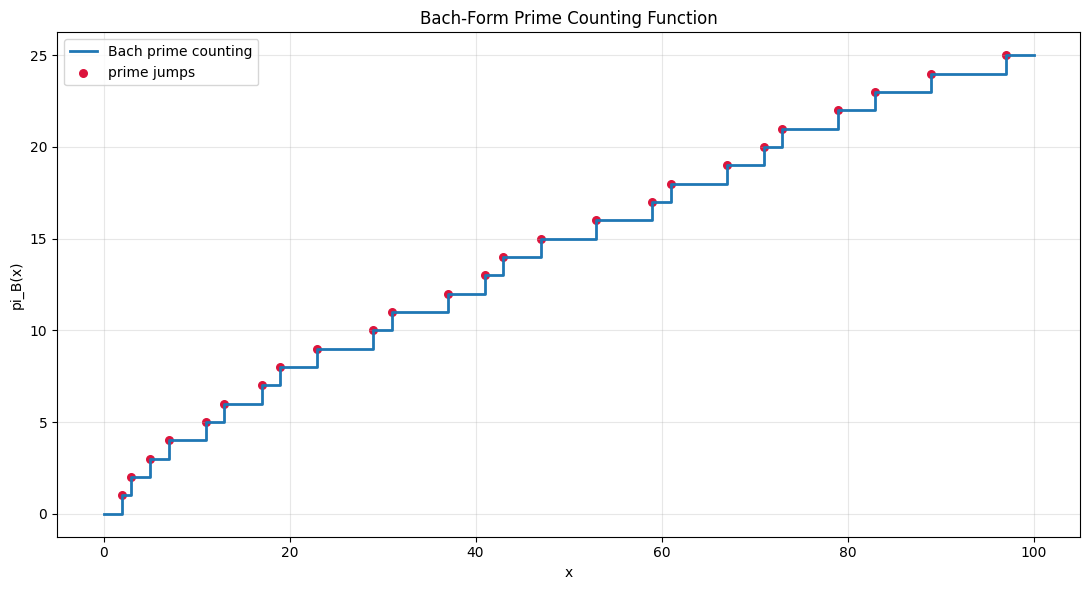

In [8]:
import matplotlib.pyplot as plt


LIMIT = 100


def bach_prime_indicator(n):
    if n < 2:
        return 0

    for m in range(2, n):
        if n % m == 0:
            return 0

    return 1


xs = list(range(LIMIT + 1))
counts = []
running_total = 0

prime_x = []
prime_y = []

for n in xs:
    is_prime = bach_prime_indicator(n)
    running_total += is_prime
    counts.append(running_total)

    if is_prime == 1:
        prime_x.append(n)
        prime_y.append(running_total)


plt.figure(figsize=(11, 6))

plt.step(xs, counts, where="post", linewidth=2, label="Bach prime counting")
plt.scatter(prime_x, prime_y, color="crimson", s=30, label="prime jumps")

plt.title("Bach-Form Prime Counting Function")
plt.xlabel("x")
plt.ylabel("pi_B(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Solutions to B(n) = 0:
[101, 103, 107, 109, 113, 127, 131, 137, 139, 149]
Number of solutions: 10


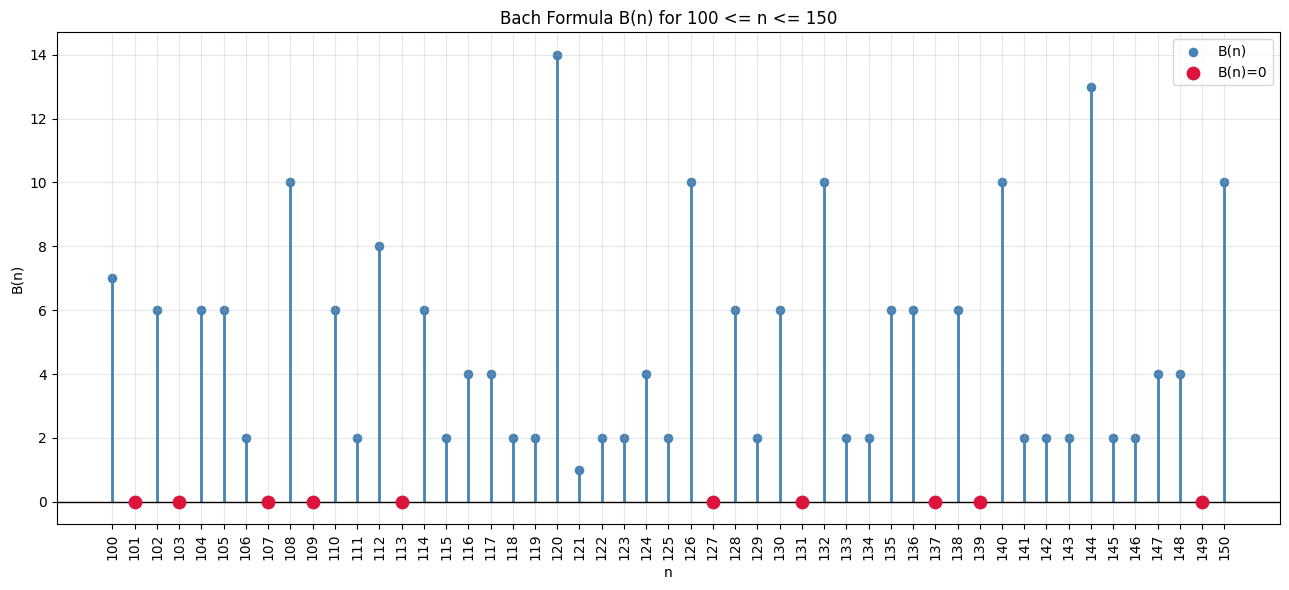

In [9]:
import matplotlib.pyplot as plt


START = 100
END = 150


def bach_B(n):
    """
    Bach's formula at integer n.

    B(n) counts the divisors of n between 2 and n-1.
    Therefore B(n) = 0 exactly when n is prime.
    """
    count = 0

    for m in range(2, n):
        if n % m == 0:
            count += 1

    return count


ns = list(range(START, END + 1))
values = [bach_B(n) for n in ns]

zero_ns = [n for n, b in zip(ns, values) if b == 0]
zero_values = [0 for _ in zero_ns]

print("Solutions to B(n) = 0:")
print(zero_ns)
print("Number of solutions:", len(zero_ns))

plt.figure(figsize=(13, 6))

plt.vlines(ns, 0, values, color="steelblue", linewidth=2)
plt.scatter(ns, values, color="steelblue", s=35, label="B(n)")
plt.scatter(zero_ns, zero_values, color="crimson", s=80, zorder=5, label="B(n)=0")

plt.axhline(0, color="black", linewidth=1)
plt.title("Bach Formula B(n) for 100 <= n <= 150")
plt.xlabel("n")
plt.ylabel("B(n)")
plt.xticks(ns, rotation=90)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

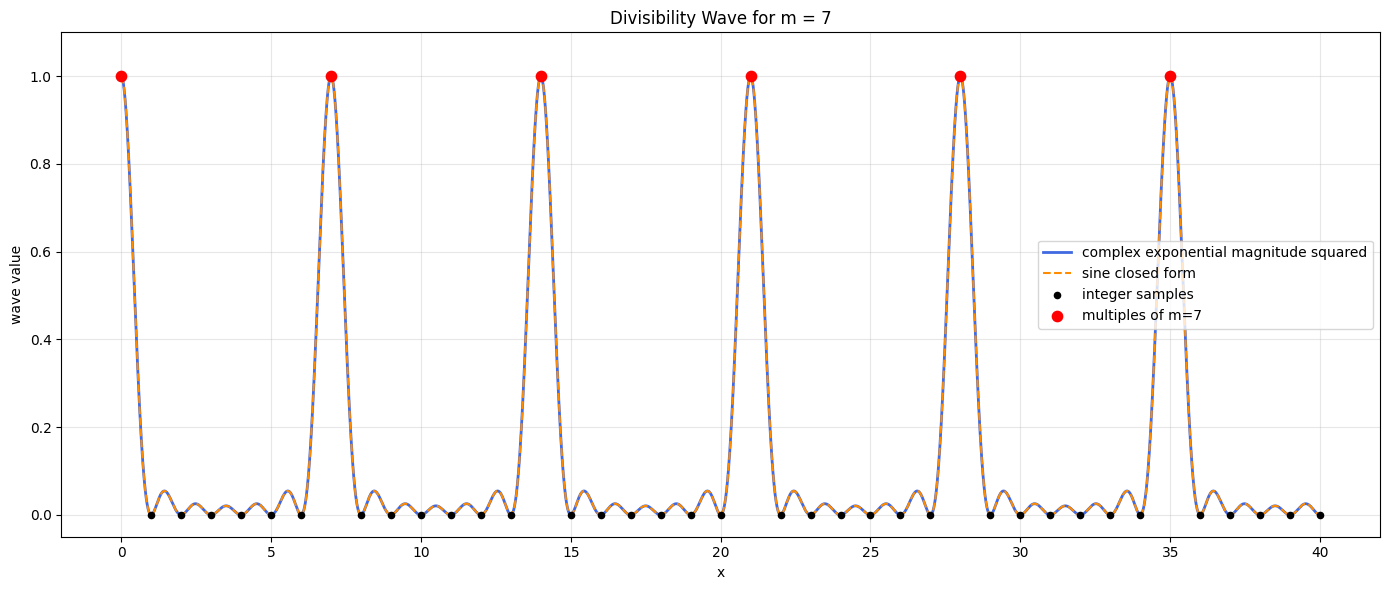

In [10]:
import numpy as np
import matplotlib.pyplot as plt


# Choose which divisor-wave to plot
m = 7

# Choose x range
X_MIN = 0
X_MAX = 40
SAMPLES = 5000


def complex_wave_magnitude_squared(m, x):
    """
    Left side:

    | (1/m) * sum_{j=0}^{m-1} exp(2*pi*i*j*x/m) |^2
    """
    x = np.asarray(x, dtype=float)
    total = np.zeros_like(x, dtype=complex)

    for j in range(m):
        total += np.exp(2j * np.pi * j * x / m)

    return np.abs(total / m) ** 2


def sine_wave_squared(m, x):
    """
    Right side:

    ( sin(pi*x) / (m*sin(pi*x/m)) )^2

    Uses the limiting value 1 at multiples of m.
    """
    x = np.asarray(x, dtype=float)

    numerator = np.sin(np.pi * x)
    denominator = m * np.sin(np.pi * x / m)

    y = np.zeros_like(x)

    regular = np.abs(denominator) > 1e-12
    y[regular] = (numerator[regular] / denominator[regular]) ** 2

    # At x = multiple of m, the limit is 1
    y[~regular] = 1.0

    return y


x = np.linspace(X_MIN, X_MAX, SAMPLES)

y_complex = complex_wave_magnitude_squared(m, x)
y_sine = sine_wave_squared(m, x)

plt.figure(figsize=(14, 6))

plt.plot(
    x,
    y_complex,
    color="royalblue",
    linewidth=2,
    label="complex exponential magnitude squared"
)

plt.plot(
    x,
    y_sine,
    color="darkorange",
    linestyle="--",
    linewidth=1.5,
    label="sine closed form"
)

# Mark integer points
integers = np.arange(int(X_MIN), int(X_MAX) + 1)
integer_values = complex_wave_magnitude_squared(m, integers)

plt.scatter(
    integers,
    integer_values,
    color="black",
    s=20,
    zorder=5,
    label="integer samples"
)

# Mark multiples of m
multiples = np.arange(0, int(X_MAX) + 1, m)
multiple_values = complex_wave_magnitude_squared(m, multiples)

plt.scatter(
    multiples,
    multiple_values,
    color="red",
    s=55,
    zorder=6,
    label=f"multiples of m={m}"
)

plt.title(f"Divisibility Wave for m = {m}")
plt.xlabel("x")
plt.ylabel("wave value")
plt.ylim(-0.05, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f2(n):
    return 0.5 * (1 + np.exp(2j * np.pi * n / 2))

x = np.linspace(0, 20, 2000)
y = f2(x)

n = np.arange(0, 21)
yn = f2(n)

plt.figure(figsize=(10, 5))

plt.plot(x, y.real, label="Re f₂(n)")
plt.plot(x, y.imag, label="Im f₂(n)", alpha=0.7)

plt.scatter(n, yn.real, color="black", zorder=3, label="integer values")

plt.axhline(0, color="gray", linewidth=0.8)
plt.axhline(1, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel("n")
plt.ylabel("f₂(n)")
plt.title(r"$f_2(n)=\frac12(1+e^{2\pi i n/2})$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ValueError: 
f_2(n)=\frac12(1+e^{2\pi i n/2})
            ^
ParseSyntaxException: Expected \frac{num}{den}, found '12'  (at char 12), (line:1, col:13)

<Figure size 1000x500 with 1 Axes>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f2(n):
    return 0.5 * (1 + np.exp(2j * np.pi * n / 2))

x = np.linspace(0, 20, 2000)
y = f2(x)

n = np.arange(0, 21)
yn = f2(n)

plt.figure(figsize=(10, 5))

plt.plot(x, y.real, label="Re f₂(n)")
plt.plot(x, y.imag, label="Im f₂(n)", alpha=0.7)

plt.scatter(n, yn.real, color="black", zorder=3, label="integer values")

plt.axhline(0, color="gray", linewidth=0.8)
plt.axhline(1, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel("n")
plt.ylabel("f₂(n)")
plt.title(r"$f_2(n)=\frac12(1+e^{2\pi i n/2})$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ValueError: 
f_2(n)=\frac12(1+e^{2\pi i n/2})
            ^
ParseSyntaxException: Expected \frac{num}{den}, found '12'  (at char 12), (line:1, col:13)

<Figure size 1000x500 with 1 Axes>

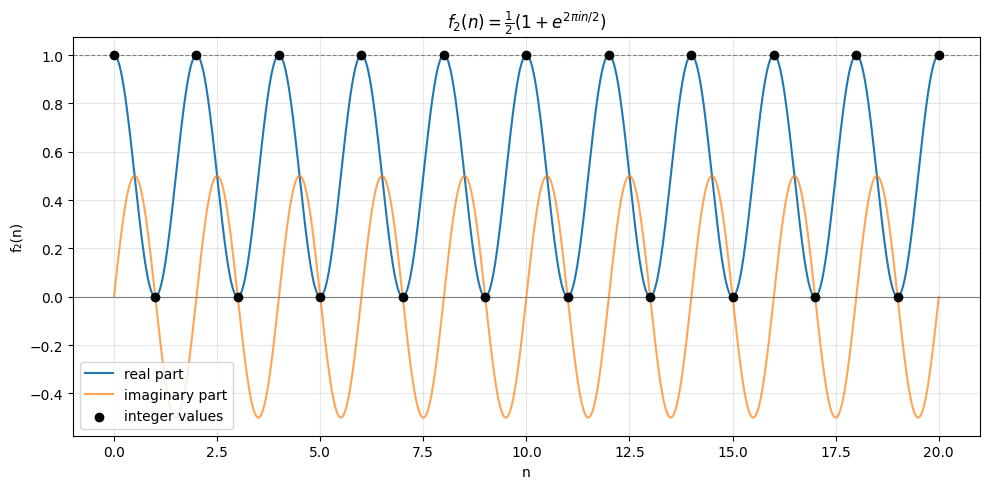

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f2(x):
    return 0.5 * (1 + np.exp(2j * np.pi * x / 2))

x = np.linspace(0, 20, 2000)
y = f2(x)

n = np.arange(0, 21)
yn = f2(n)

plt.figure(figsize=(10, 5))

plt.plot(x, y.real, label="real part")
plt.plot(x, y.imag, label="imaginary part", alpha=0.7)

plt.scatter(n, yn.real, color="black", zorder=3, label="integer values")

plt.axhline(0, color="gray", linewidth=0.8)
plt.axhline(1, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel("n")
plt.ylabel("f₂(n)")
plt.title(r"$f_2(n)=\frac{1}{2}\left(1+e^{2\pi i n/2}\right)$")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

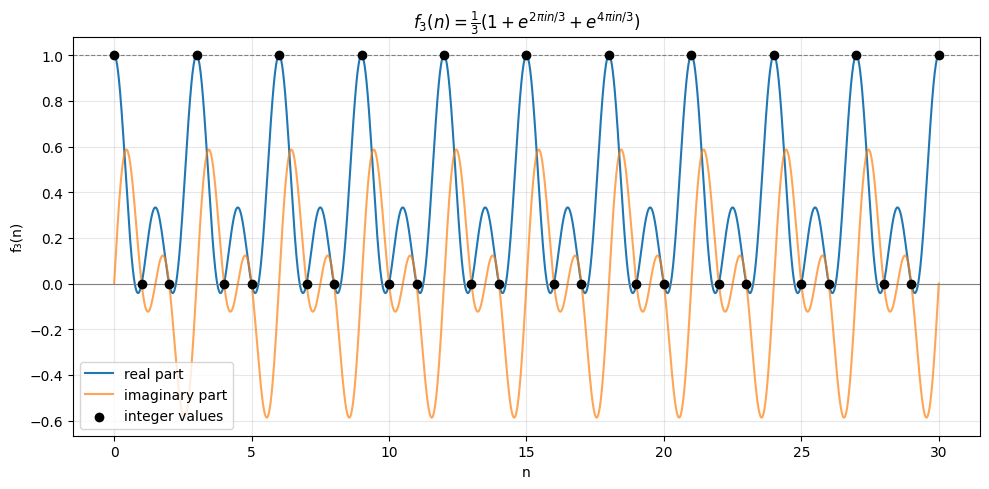

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def f3(x):
    return (1/3) * (
        1
        + np.exp(2j * np.pi * x / 3)
        + np.exp(4j * np.pi * x / 3)
    )

x = np.linspace(0, 30, 3000)
y = f3(x)

n = np.arange(0, 31)
yn = f3(n)

plt.figure(figsize=(10, 5))

plt.plot(x, y.real, label="real part")
plt.plot(x, y.imag, label="imaginary part", alpha=0.7)

plt.scatter(n, yn.real, color="black", zorder=3, label="integer values")

plt.axhline(0, color="gray", linewidth=0.8)
plt.axhline(1, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel("n")
plt.ylabel("f₃(n)")
plt.title(
    r"$f_3(n)=\frac{1}{3}\left(1+e^{2\pi i n/3}+e^{4\pi i n/3}\right)$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

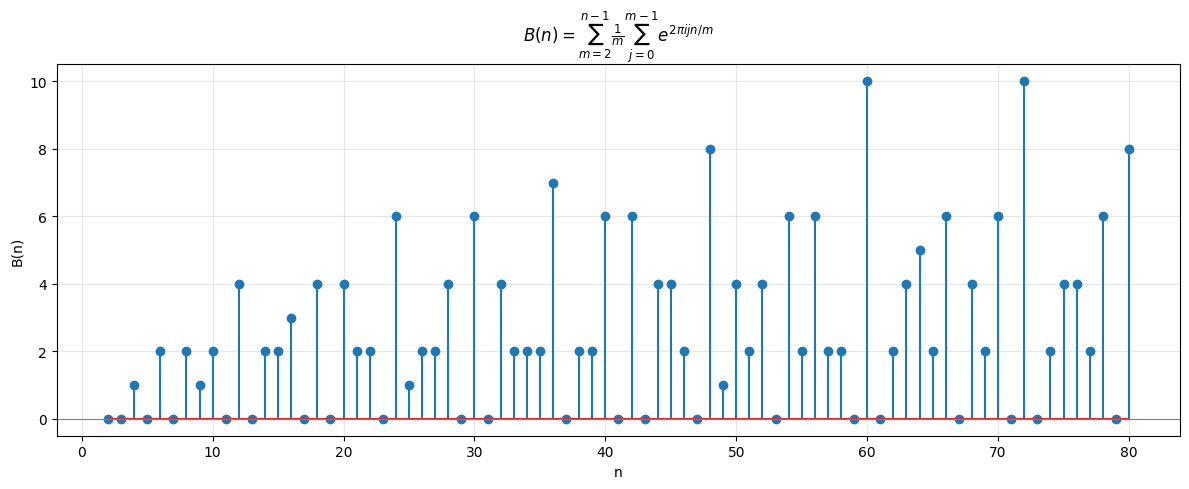

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def bach(n):
    total = 0

    for m in range(2, n):
        wave = 0

        for j in range(m):
            wave += np.exp(2j * np.pi * j * n / m)

        total += wave / m

    return total

N = 80
n_values = np.arange(2, N + 1)
B_values = np.array([bach(n) for n in n_values])

plt.figure(figsize=(12, 5))

plt.stem(n_values, B_values.real)

plt.axhline(0, color="gray", linewidth=0.8)

plt.xlabel("n")
plt.ylabel("B(n)")
plt.title(
    r"$B(n)=\sum_{m=2}^{n-1}\frac{1}{m}\sum_{j=0}^{m-1}e^{2\pi ijn/m}$"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()